In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

/Users/vikaspandey/projects/genesis-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


In [2]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

In [3]:
train_data = dataset["train"]
text_list = train_data["text"]
text_list_cleaned = [
    text for text in text_list 
    if text.strip() and not text.strip().startswith("=")
]
text_list_cleaned[2]

" It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , it received downloadable content , along with an expanded edition in November of that year . It was also adapted into manga and an original video animation series . Due to low sales of Valkyria Chronicles II , Valkyria Chronicles III was not localized , but a fan translation compatible with the game 's expanded edition was released in 2014 . Media.Vision would return to the franchise with the development of Valkyria : Azure Revolution for the PlayStation 4 . \n"

In [4]:

vocab = list()
word_to_idx = {}
idx_to_word = {}
word_freq = {}
all_words = []
for text in text_list_cleaned:
    for word in text.strip().split():
        all_words.append(word)
        word_freq[word] = word_freq.get(word, 0) + 1
vocab = [word for word, freq in word_freq.items() if freq >= 3]
words_with_low_freq = set([word for word, freq in word_freq.items() if freq < 3])
for i, word in enumerate(all_words):
    if word in words_with_low_freq:
        all_words[i] = "<UNK>"
vocab.append("<UNK>")
vocab.append("<START>")
vocab.append("<END>")
for idx, word in enumerate(vocab):
    word_to_idx[word] = idx
    idx_to_word[idx] = word
len(vocab)

32997

In [5]:
def build_dataset(all_words, context_len=4):
    X, Y = [], []
    context = [word_to_idx["<START>"]]*context_len
    for word in all_words:
        X.append(context)
        Y.append(word_to_idx[word])
        context = context[1:] + [word_to_idx[word]]
    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    return X, Y

def plot_losses(train_losses, val_losses, title="Training and Validation Loss"):
    """
    Function to plot Training and Validation Loss against Epochs.
    
    Parameters:
    - train_losses: ek list jisme har epoch ka average training loss ho.
    - val_losses: ek list jisme har epoch ka validation loss ho.
    - title: Graph ka uper ka title
    """
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(20, 10))
    plt.plot(epochs, train_losses, 'b-o', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-s', label='Validation Loss')
    
    plt.title(title, fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    plt.xticks(epochs) # taki har epoch ka number dikhe x-axis par
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [6]:
embed_dim = 60 # changed
hidden_dim = 50 # changed
context_len = 5
batch_size = 256
num_epochs = 50
learning_rate = 0.1
vocab_size = len(vocab)
r = 1e-8

In [8]:
n1 = int(0.8*len(all_words))
n2 = int(0.9*len(all_words))

train_x, train_y = build_dataset(all_words[:n1], context_len=context_len)
val_x, val_y = build_dataset(all_words[n1:n2], context_len=context_len)
test_x, test_y = build_dataset(all_words[n2:], context_len=context_len)

train_x,  train_y = train_x.to(device), train_y.to(device)

print(train_x.shape, train_y.shape)
print(val_x.shape, val_y.shape)
print(test_x.shape, test_y.shape)
print(train_x)

torch.Size([1605716, 5]) torch.Size([1605716])
torch.Size([200715, 5]) torch.Size([200715])
torch.Size([200715, 5]) torch.Size([200715])
tensor([[32995, 32995, 32995, 32995, 32995],
        [32995, 32995, 32995, 32995,     0],
        [32995, 32995, 32995,     0,     1],
        ...,
        [ 6322, 13003,     6,  4129, 17180],
        [13003,     6,  4129, 17180,    15],
        [    6,  4129, 17180,    15,    11]], device='mps:0')


In [12]:
class BengioNPLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, context_len):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.context_len = context_len

        self.C = nn.Embedding(vocab_size, embed_dim)
        self.W1 = nn.Linear(context_len * embed_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, vocab_size)
        self.W_direct = nn.Linear(context_len * embed_dim, vocab_size)

    def forward(self, x):
        x = self.C(x)
        e = x.view(-1, self.context_len * self.embed_dim)
        h = torch.tanh(self.W1(e))
        out = self.W2(h) + self.W_direct(e)
        return out

def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            logits = model(data)
            loss = criterion(logits, target)
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    perplexity = torch.exp(torch.tensor(avg_loss))
    return avg_loss, perplexity


In [13]:
model = BengioNPLM(vocab_size, embed_dim, hidden_dim, context_len)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer=optimizer, lr_lambda=lambda t: (1 / (1 + r*t)))

In [15]:
type(optimizer)

torch.optim.sgd.SGD

In [9]:
train_dataset = TensorDataset(train_x, train_y)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

val_dataset = TensorDataset(val_x, val_y)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(test_x, test_y)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = BengioNPLM(vocab_size, embed_dim, hidden_dim, context_len)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer=optimizer, lr_lambda=lambda t: (1 / (1 + r*t)))
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        logits = model(data)
        loss = criterion(logits, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    perplexity = torch.exp(torch.tensor(avg_loss))
    val_loss, val_perplexity = evaluate(model, val_loader, criterion)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}, Val PPL: {val_perplexity:.2f}")

Epoch 1, Train Loss: 7.2084, Val Loss: 6.8219, Val PPL: 917.77
Epoch 2, Train Loss: 6.5609, Val Loss: 6.6493, Val PPL: 772.28
Epoch 3, Train Loss: 6.3692, Val Loss: 6.5643, Val PPL: 709.32
Epoch 4, Train Loss: 6.2517, Val Loss: 6.5077, Val PPL: 670.27
Epoch 5, Train Loss: 6.1686, Val Loss: 6.4709, Val PPL: 646.10
Epoch 6, Train Loss: 6.1055, Val Loss: 6.4417, Val PPL: 627.47
Epoch 7, Train Loss: 6.0560, Val Loss: 6.4155, Val PPL: 611.24
Epoch 8, Train Loss: 6.0156, Val Loss: 6.3966, Val PPL: 599.81
Epoch 9, Train Loss: 5.9822, Val Loss: 6.3741, Val PPL: 586.48
Epoch 10, Train Loss: 5.9544, Val Loss: 6.3597, Val PPL: 578.08
Epoch 11, Train Loss: 5.9309, Val Loss: 6.3439, Val PPL: 568.99
Epoch 12, Train Loss: 5.9105, Val Loss: 6.3347, Val PPL: 563.80
Epoch 13, Train Loss: 5.8927, Val Loss: 6.3216, Val PPL: 556.45
Epoch 14, Train Loss: 5.8768, Val Loss: 6.3099, Val PPL: 549.99
Epoch 15, Train Loss: 5.8625, Val Loss: 6.2980, Val PPL: 543.47
Epoch 16, Train Loss: 5.8494, Val Loss: 6.2895, V

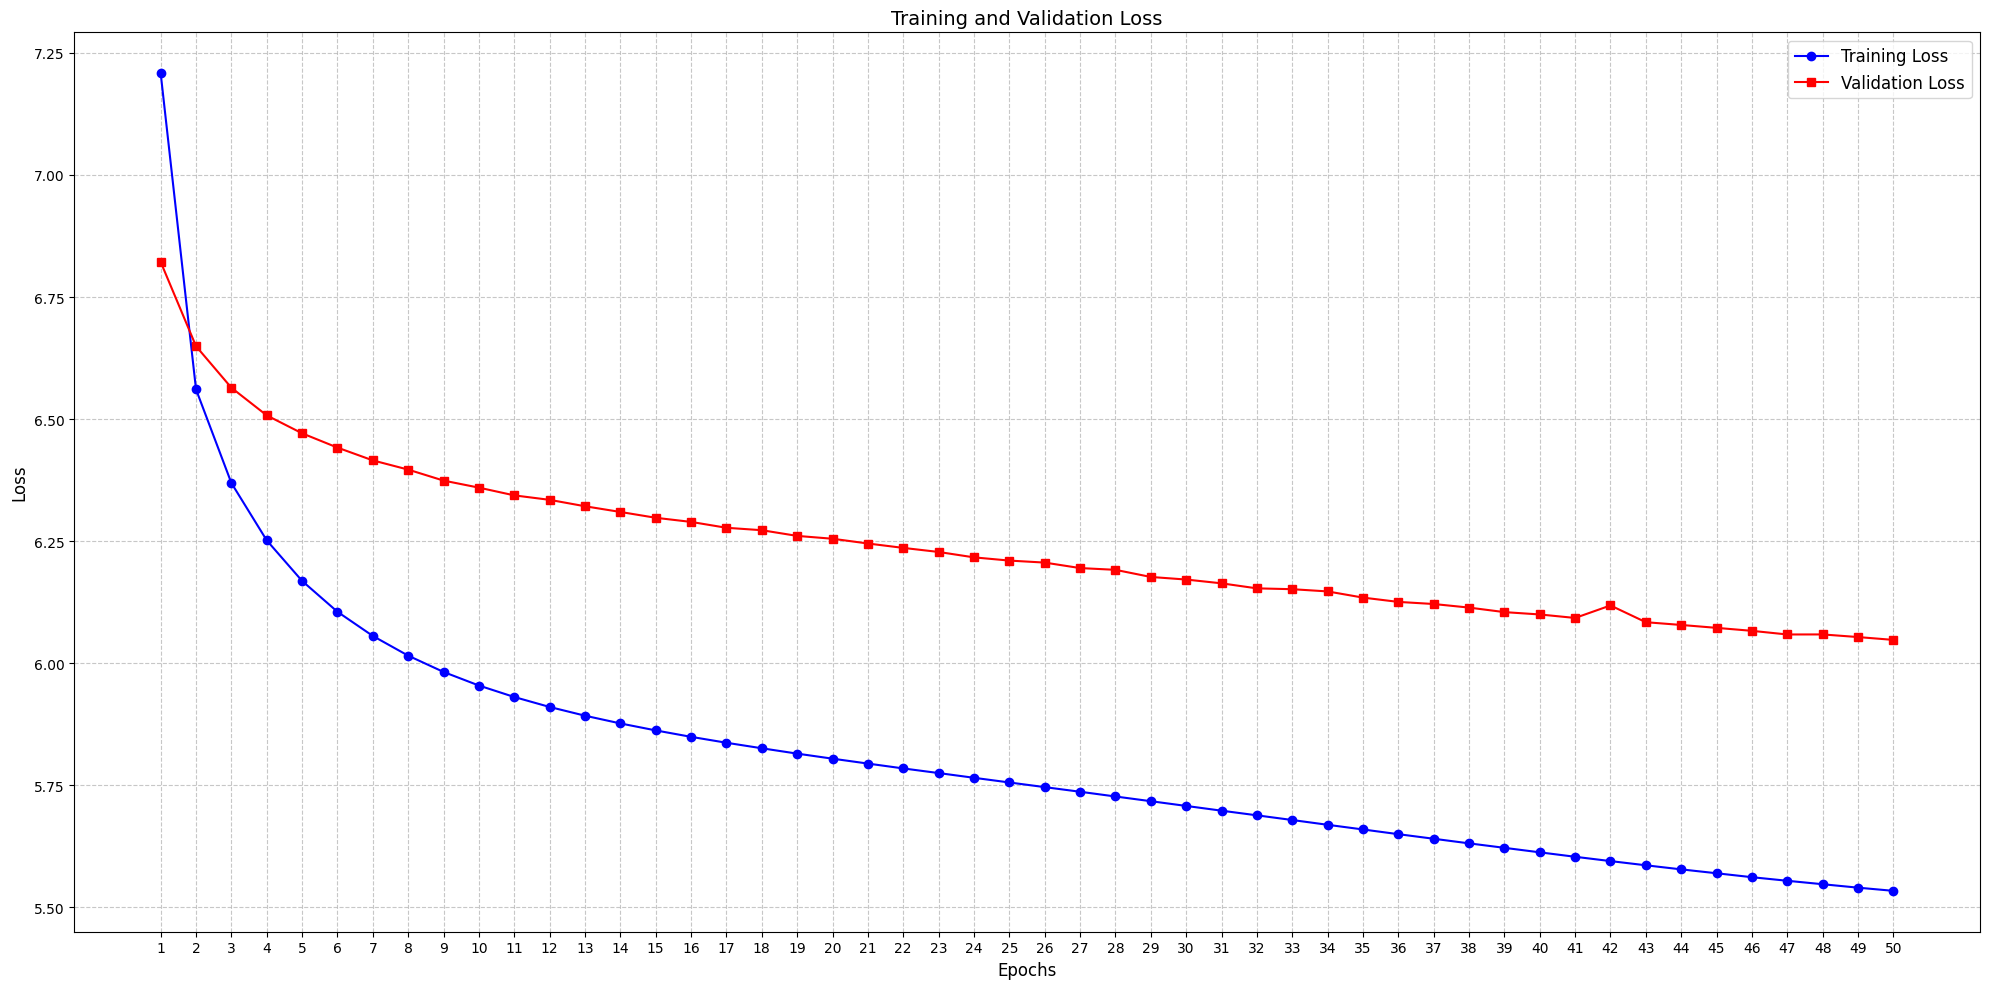

In [18]:
plot_losses(train_losses, val_losses)

In [20]:
val_loss, val_perplexity = evaluate(model, val_loader, criterion)
test_loss, test_perplexity = evaluate(model, test_loader, criterion)
print(f"Validation Loss: {val_loss:.4f}, Validation Perplexity: {val_perplexity:.2f}")
print(f"Test Loss: {test_loss:.4f}, Test Perplexity: {test_perplexity:.2f}")

Validation Loss: 6.0479, Validation Perplexity: 423.22
Test Loss: 6.0750, Test Perplexity: 434.86


# 📊 Bengio 2003 Model - Experiments Tracking

**Data:** Wikitext-2 | **Model Architecture:** MLP Language Model | **Base Task:** Next Word/Token Prediction

| Exp ID | Cont. (n) | Emb (m) | Hidden | Batch | Epochs | Optimizer | LR | Val Loss | Val PPL | Test Loss | Test PPL | Notes & Key Changes |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **#1** | 4 | 30 | 50 | 128 | 10 | Adam/AdamW | 0.001 | 6.5636 | 708.80 | 6.6415 | 766.21 | Baseline Run. |
| **#2** | 4 | 60 | 50 | 128 | 10 | Adam/AdamW | 0.001 | 6.8635 | 956.73 | 6.9399 | 1032.63 | **Emb = 60**. Performance degrade hui. |
| **#3** | 4 | 30 | 60 | 128 | 10 | Adam/AdamW | 0.001 | **5.8329** | **341.34** | **5.8756** | **356.22** | **Hidden=60, L2(Weight Decay)=1e-5**. Best performance. |
| **#4** | 4 | 30 | 60 | 128 | 30 | SGD | 0.1 | 6.3166 | 553.69 | 6.3588 | 577.55 | **SGD, Epochs=30, LR=0.1, r(decay)=1e-8**. Adam ke samne underperform, but baseline se thik hai. |
| **#5** | 5 | 60 | 50 | 256 | 50 | SGD | 0.1 | 6.0479 | 423.22 | 6.0750 | 434.86 | **SGD, Epochs=50, Batch=256, Emb=60, Cont=5, L2=1e-4**. Fixed evaluation crash. Performance is much better compared to Exp #4. |
